In [2]:
import torch

pt_path = "C:\\Users\\yxu59\\files\\autumn2025\\park\\DynamicCalibration\\cfg2_26011501_40_bocpdpf_diag_Standard_diag_infos.pt"
diag = torch.load(pt_path, map_location="cpu",weights_only=False)

type(diag), diag.keys()


(dict,
 dict_keys([0, 40, 80, 120, 160, 200, 240, 280, 320, 360, 400, 440, 480, 520, 560, 600, 640, 680, 720, 760, 800, 840, 880, 920, 960, 1000, 1040, 1080, 1120, 1160, 1200, 1240, 1280, 1320, 1360, 1400, 1440, 1480, 1520, 1560, 1600, 1640, 1680, 1720, 1760, 1800, 1840, 1880, 1920, 1960, 2000, 2040, 2080, 2120, 2160, 2200, 2240, 2280, 2320, 2360, 2400, 2440, 2480, 2520, 2560, 2600, 2640, 2680, 2720, 2760, 2800, 2840, 2880, 2920, 2960, 3000, 3040, 3080, 3120, 3160, 3200, 3240, 3280, 3320, 3360, 3400, 3440, 3480, 3520, 3560, 3600, 3640, 3680, 3720, 3760, 3800, 3840, 3880, 3920, 3960]))

In [6]:
rmse_spike_batches = []

for t, info in diag.items():
    if "rmse" in info and info["rmse"] > 1.0:
        rmse_spike_batches.append(t)

for t in rmse_spike_batches:
    print(f"batch key = {t}, rmse = {diag[t]['rmse']:.4f}")



batch key = 800, rmse = 3.2840
batch key = 840, rmse = 4.3523
batch key = 920, rmse = 1.3265
batch key = 1000, rmse = 1.2223
batch key = 1160, rmse = 1.9935
batch key = 1240, rmse = 1.3530
batch key = 1280, rmse = 2.9080
batch key = 1320, rmse = 4.0747
batch key = 1400, rmse = 1.0900
batch key = 1600, rmse = 2.0647
batch key = 1640, rmse = 1.5290
batch key = 2400, rmse = 3.5831
batch key = 2440, rmse = 2.5522
batch key = 3200, rmse = 3.9393
batch key = 3240, rmse = 2.6124
batch key = 3280, rmse = 2.6548
batch key = 3320, rmse = 54.3184


In [9]:
diag[3320].keys()

dict_keys(['data', 'pred', 'rmse', 'crps', 'theta'])

In [35]:
diag[3320]['pred']['experts_res'][0].keys()

dict_keys(['mu_delta', 'var_delta', 'w', 'mu', 'var'])

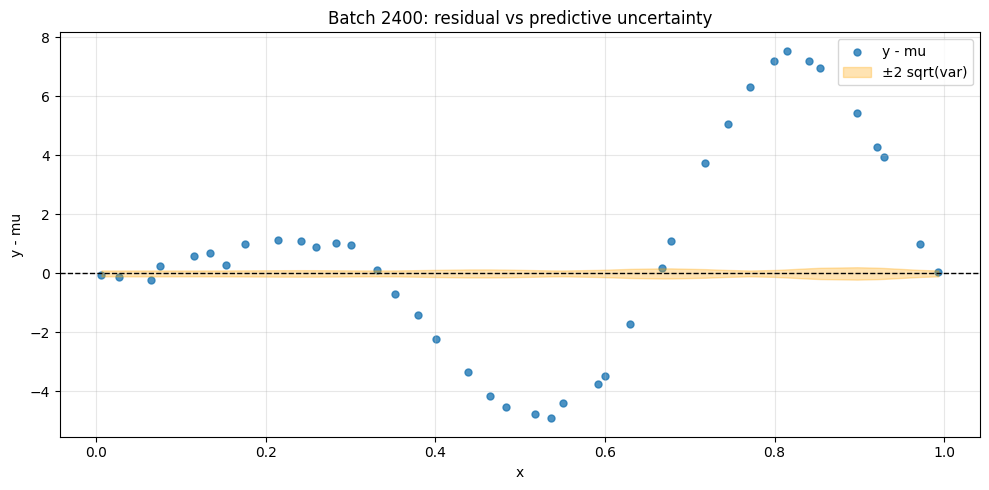

In [17]:
diag_infos = diag

import numpy as np
import matplotlib.pyplot as plt

# t = 3320
t = 2400
info = diag_infos[t]

X = info["data"]["X"].reshape(-1)
Y = info["data"]["Y"].reshape(-1)

mu  = info["pred"]["mu"].reshape(-1)
var = info["pred"]["var"].reshape(-1)

residual = Y - mu
std = np.sqrt(var)

idx = np.argsort(X)

X_s   = X[idx]
res_s = residual[idx]
std_s = std[idx]

plt.figure(figsize=(10, 5))

# 残差点
plt.scatter(X_s, res_s, s=25, alpha=0.8, label="y - mu")

# 不确定性带
plt.fill_between(
    X_s,
    -2 * std_s,
    2 * std_s,
    color="orange",
    alpha=0.3,
    label="±2 sqrt(var)"
)

# y=0 参考线
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)

plt.xlabel("x")
plt.ylabel("y - mu")
plt.title(f"Batch {t}: residual vs predictive uncertainty")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt

t = 2400
info = diag_infos[t]

X = info["data"]["X"].reshape(-1)
Y = info["data"]["Y"].reshape(-1)

experts_res = info["pred"]["experts_res"]
n_expert = len(experts_res)

print("Number of experts:", n_expert)


Number of experts: 5


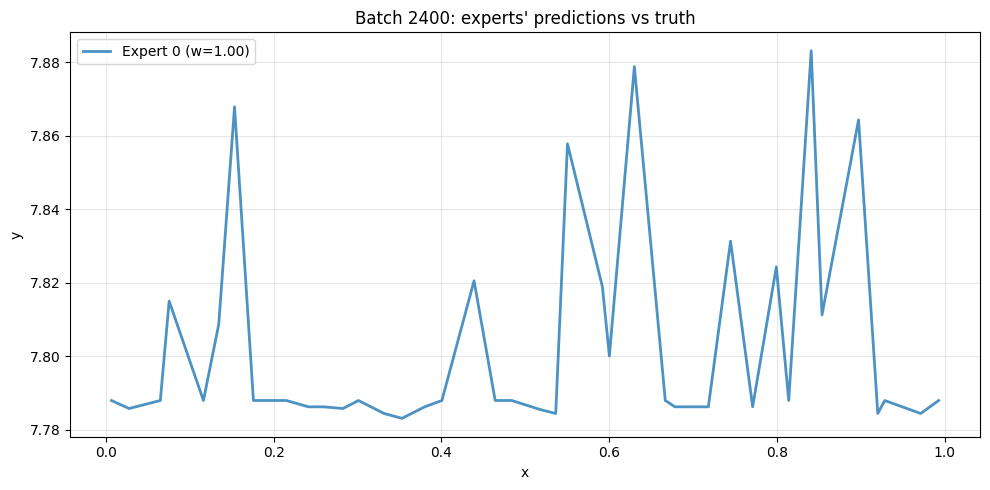

In [19]:
# 为了画得清楚，先按 x 排序
idx = np.argsort(X)
X_s = X[idx]
Y_s = Y[idx]

plt.figure(figsize=(10, 5))

# 真值
# plt.scatter(X_s, Y_s, s=25, color="black", label="Y (truth)", zorder=5)

# 每个 expert 的预测
for k, er in enumerate(experts_res):
    mu_k = er["mu"].reshape(-1)[idx]
    w_k  = er["w"]
    plt.plot(
        X_s,
        mu_k,
        linewidth=2,
        alpha=0.8,
        label=f"Expert {k} (w={w_k:.2f})"
    )
    break

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Batch {t}: experts' predictions vs truth")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
theta_particles, logw = diag_infos[2400]["theta"][0]

w = np.exp(logw - logw.max())
w /= w.sum()

w1 = torch.logsumexp(logw, dim=0)
logw1 = logw - w1
w1 = torch.exp(logw1)
m = (w1[:, None] * theta_particles).sum(0)
C = ((theta_particles - m) * w1[:, None]).T @ (theta_particles - m)

print("theta mean:", m)
print("theta std :", np.sqrt(C.sum()))


theta mean: tensor([3.0033], dtype=torch.float64)
theta std : tensor(0.0869, dtype=torch.float64)


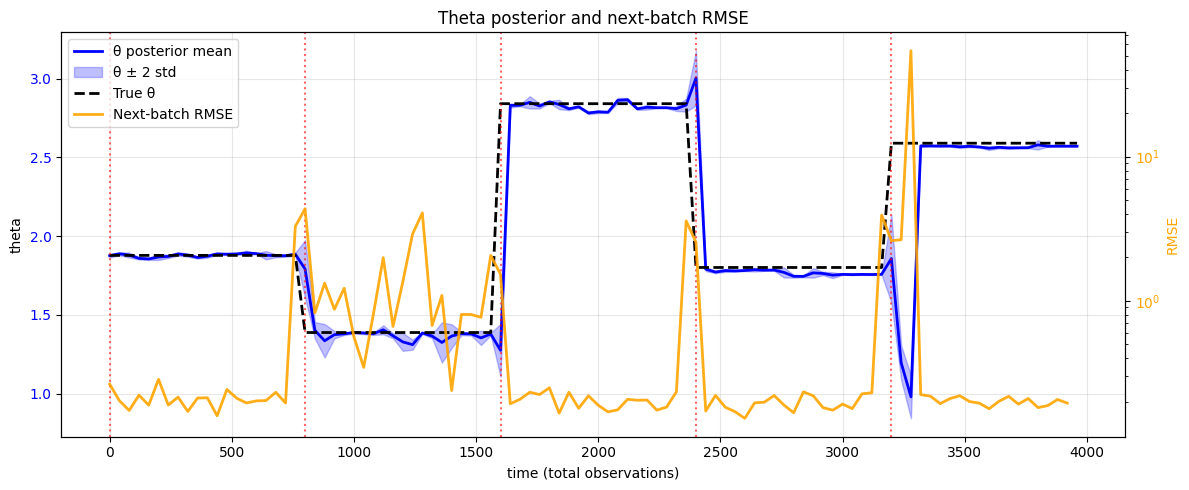

In [32]:
import numpy as np
import torch
import matplotlib.pyplot as plt

times = []
theta_mean = []
theta_std = []

for t in sorted(diag_infos.keys()):
    # 只取 expert 0
    theta_particles, logw = diag_infos[t]["theta"][0]

    # 你的权重计算方式
    w1 = torch.logsumexp(logw, dim=0)
    logw1 = logw - w1
    w = torch.exp(logw1)

    # mean
    m = (w[:, None] * theta_particles).sum(0)

    # covariance (scalar theta → 1x1)
    C = ((theta_particles - m) * w[:, None]).T @ (theta_particles - m)

    times.append(t)
    theta_mean.append(m.item())
    theta_std.append(np.sqrt(C.sum().item()))

true_theta = []

for t in times:
    if t < 800:
        true_theta.append(1.8775)
    elif t < 1600:
        true_theta.append(1.3878)
    elif t < 2400:
        true_theta.append(2.8407)
    elif t < 3200:
        true_theta.append(1.8008)
    else:
        true_theta.append(2.5899)

times = np.array(times)
theta_mean = np.array(theta_mean)
theta_std = np.array(theta_std)
true_theta = np.array(true_theta)

import numpy as np

times = np.array(times)
theta_mean = np.array(theta_mean)
theta_std = np.array(theta_std)

# 按 time 排序的 rmse
rmse_times = sorted(diag_infos.keys())
rmse_vals = np.array([0]+[diag_infos[t]["rmse"] for t in rmse_times if t>0])

rmse_times = np.array(rmse_times)

# 对齐：rmse(t+1) 画在 theta(t)
rmse_shifted = np.full_like(theta_mean, np.nan, dtype=float)

for i, t in enumerate(times):
    if t + 40 in diag_infos:   # batch size = 40
        rmse_shifted[i] = diag_infos[t + 40]["rmse"]


# plt.figure(figsize=(11, 5))

# # θ mean
# plt.plot(times, theta_mean, color="blue", linewidth=2, label="Posterior mean")

# # 不确定性带
# plt.fill_between(
#     times,
#     theta_mean - 2 * theta_std,
#     theta_mean + 2 * theta_std,
#     color="blue",
#     alpha=0.25,
#     label="± 2 std"
# )

# # 真值 θ（piecewise）
# plt.plot(
#     times,
#     true_theta,
#     color="black",
#     linestyle="--",
#     linewidth=2,
#     label="True θ"
# )

# # changepoint 竖线
# for cp in [0, 800, 1600, 2400, 3200]:
#     plt.axvline(cp, color="red", linestyle=":", alpha=0.7)

# plt.xlabel("time (total observations)")
# plt.ylabel("theta")
# plt.title("Theta posterior over time (expert 0)")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

# ===== 左轴：theta =====
ax1.plot(times, theta_mean, color="blue", linewidth=2, label="θ posterior mean")
ax1.fill_between(
    times,
    theta_mean - 2 * theta_std,
    theta_mean + 2 * theta_std,
    color="blue",
    alpha=0.25,
    label="θ ± 2 std"
)

# 真值 θ
ax1.plot(
    times,
    true_theta,
    color="black",
    linestyle="--",
    linewidth=2,
    label="True θ"
)

ax1.set_xlabel("time (total observations)")
ax1.set_ylabel("theta")
ax1.tick_params(axis="y", labelcolor="blue")

# changepoint 竖线
for cp in [0, 800, 1600, 2400, 3200]:
    ax1.axvline(cp, color="red", linestyle=":", alpha=0.6)

# ===== 右轴：RMSE =====
ax2 = ax1.twinx()
ax2.plot(
    times,
    rmse_shifted,
    color="orange",
    linewidth=2,
    alpha=0.9,
    label="Next-batch RMSE"
)
ax2.set_ylabel("RMSE", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.set_yscale("log")   # 🔥 强烈建议用 log scale

# ===== 图例合并 =====
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Theta posterior and next-batch RMSE")
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [42]:
import numpy as np
import pandas as pd

records = []

for t in sorted(diag_infos.keys()):
    if t==0:
        continue
    info = diag_infos[t]

    X = info["data"]["X"].reshape(-1)
    Y = info["data"]["Y"].reshape(-1)

    experts_res = info["pred"]["experts_res"]

    for k, er in enumerate(experts_res):
        mu_k = torch.tensor(er["mu"]).reshape(-1)
        w_k  = er["w"]         # expert-level weight (scalar)
        print(Y.shape, mu_k.shape)

        residual = torch.tensor(Y) - mu_k

        for i in range(len(X)):
            records.append({
                "time": t,
                "expert": k,
                "x": X[i],
                "residual": residual[i],
                "abs_residual": abs(residual[i]),
                "expert_weight": w_k,
            })

df = pd.DataFrame(records)


(40,) torch.Size([40960])


C:\Users\yxu59\AppData\Local\Temp\ipykernel_36108\1670409945.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_k = torch.tensor(er["mu"]).reshape(-1)


RuntimeError: The size of tensor a (40) must match the size of tensor b (40960) at non-singleton dimension 0